# Laboratorio de Pandas Avanzado
## Fase 3: Intersección Espacial y Visualización Integrada

**Bootcamp Python para Ciencia de Datos — PY4**  
**Módulo 1: Python y Manipulación de Datos**

---

### Contexto

En las dos fases anteriores construimos dos análisis independientes:
- **Fase 1**: limpieza de timestamps, resampling, tendencias temporales.
- **Fase 2**: GeoDataFrame, spatial join con los 77 community areas de Chicago, mapas de coropletas.

Ahora los combinamos. La pregunta central de esta sesión es:

> *¿Cómo evoluciona el uso de Divvy a lo largo del tiempo en cada vecindario de Chicago?*

Para responderla necesitamos cruzar las dos dimensiones: para cada community area, ver la tendencia semanal de viajes. Y al revés: para cada semana, ver qué zonas concentran más actividad.

En esta sesión vamos a:
1. Cargar y combinar los resultados de las fases anteriores.
2. Combinar `groupby` y `resample` para análisis temporal por zona.
3. Generar gráficos de tendencia por community area.
4. Construir mapas de calor semana a semana.
5. Producir un dashboard integrado: tendencias + mapa en una sola figura.

**Datasets:**
- Viajes Divvy enero 2024 (procesados en Fases 1 y 2)
- Community Areas de Chicago (GeoJSON)

---

## 1. Preparación del entorno

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import urllib.request
import zipfile
import io
import os
import warnings
warnings.filterwarnings('ignore')

print("Librerias cargadas")
print(f"pandas:    {pd.__version__}")
print(f"geopandas: {gpd.__version__}")

Librerias cargadas
pandas:    2.2.2
geopandas: 1.1.3


## 2. Cargar los datos de las fases anteriores

Necesitamos dos cosas: el dataset de viajes con community area asignado (resultado de la Fase 2) y el GeoDataFrame de polígonos de Chicago. Si los archivos no existen, el bloque alternativo los regenera desde cero.

In [ ]:
# --- Cargar viajes con community area ---
if os.path.exists('divvy_enero2024_geo.csv'):
    df = pd.read_csv('divvy_enero2024_geo.csv')
    df['started_at'] = pd.to_datetime(df['started_at'], utc=True)
    print(f"Viajes cargados: {len(df):,} filas")
else:
    print("Regenerando dataset completo desde Divvy...")
    URL = 'https://divvy-tripdata.s3.amazonaws.com/202401-divvy-tripdata.zip'
    req = urllib.request.Request(URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as r:
        contenido = r.read()
    with zipfile.ZipFile(io.BytesIO(contenido)) as z:
        with z.open(z.namelist()[0]) as f:
            df_raw = pd.read_csv(f)

    df_raw['started_at'] = pd.to_datetime(df_raw['started_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    df_raw['ended_at']   = pd.to_datetime(df_raw['ended_at'],   format='%Y-%m-%d %H:%M:%S', errors='coerce')
    df_raw['duracion_min'] = (df_raw['ended_at'] - df_raw['started_at']).dt.total_seconds() / 60
    df_raw = df_raw[(df_raw['duracion_min'] > 1) & (df_raw['duracion_min'] <= 180)].copy()
    df_raw['hora']       = df_raw['started_at'].dt.hour
    df_raw['dia_semana'] = df_raw['started_at'].dt.day_name()
    df_raw = df_raw.dropna(subset=['start_lat', 'start_lng'])

    GEOJSON_URL = 'https://raw.githubusercontent.com/RandomFractals/ChicagoCrimes/master/data/chicago-community-areas.geojson'
    comunidades_tmp = gpd.read_file(GEOJSON_URL)
    comunidades_tmp['community'] = comunidades_tmp['community'].str.title()

    gdf_tmp = gpd.GeoDataFrame(
        df_raw,
        geometry=[Point(lon, lat) for lon, lat in zip(df_raw['start_lng'], df_raw['start_lat'])],
        crs='EPSG:4326'
    )
    gdf_tmp = gpd.sjoin(gdf_tmp, comunidades_tmp[['community', 'area_num_1', 'geometry']], how='left', predicate='within')

    cols = ['ride_id', 'started_at', 'rideable_type', 'member_casual',
            'duracion_min', 'hora', 'dia_semana', 'start_lat', 'start_lng', 'community', 'area_num_1']
    df = gdf_tmp[cols].copy()
    df['started_at'] = df['started_at'].astype(str)
    df.to_csv('divvy_enero2024_geo.csv', index=False)
    df['started_at'] = pd.to_datetime(df['started_at'], utc=True)
    print(f"Regenerado: {len(df):,} filas")

print()

# --- Cargar community areas ---
GEOJSON_LOCAL = 'chicago_community_areas.geojson'
GEOJSON_URL   = 'https://raw.githubusercontent.com/RandomFractals/ChicagoCrimes/master/data/chicago-community-areas.geojson'

if os.path.exists(GEOJSON_LOCAL):
    comunidades = gpd.read_file(GEOJSON_LOCAL)
else:
    comunidades = gpd.read_file(GEOJSON_URL)
    comunidades.to_file(GEOJSON_LOCAL, driver='GeoJSON')

comunidades['community'] = comunidades['community'].str.title()
print(f"Community areas cargados: {len(comunidades)}")
print()
print("Todo listo.")

Viajes cargados: 139,704 filas

Community areas cargados: 77

Todo listo.


## 3. Preparar la serie temporal

Para poder aplicar `resample`, necesitamos que `started_at` sea el index del DataFrame. También vamos a quedarnos solo con los viajes que tienen community area asignado (los que quedaron fuera de Chicago los dejamos afuera).

In [ ]:
# Filtrar viajes con community area válido
df_clean = df.dropna(subset=['community']).copy()
print(f"Viajes con community area: {len(df_clean):,}")
print(f"Viajes fuera de Chicago:   {df['community'].isnull().sum():,}")

# Establecer el index temporal
df_clean = df_clean.set_index('started_at').sort_index()

print(f"\nRango temporal: {df_clean.index.min()} → {df_clean.index.max()}")
print(f"Tipo del index: {type(df_clean.index)}")

Viajes con community area: 137,998
Viajes fuera de Chicago:   1,706

Rango temporal: 2024-01-01 00:00:39+00:00 → 2024-01-31 23:59:40+00:00
Tipo del index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 4. Combinar temporal + espacial: groupby + resample

Este es el paso central de la sesión. Queremos saber, para cada community area y cada semana, cuántos viajes se realizaron.

La estrategia combina dos operaciones que ya conocemos:
- `groupby('community')`: agrupa por vecindario.
- `resample('W')`: dentro de cada vecindario, agrupa por semana.

En Pandas estas dos operaciones se pueden encadenar directamente.

In [ ]:
# Viajes por community area y por semana
viajes_zona_semana = (
    df_clean # dataset limpio que contiene los viajes
    .groupby('community') # agrupa los registros por community area (barrio/zona)
    .resample('W')['ride_id'] # dentro de cada community area, agrupa los datos por semana ('W' = weekly), usando el índice temporal del DataFrame, luego selecciona la columna ride_id
    .count() # cuenta cuántos viajes hubo en cada community area y en cada semana
)

print("Resultado (MultiIndex: community + semana):")
print(viajes_zona_semana.head(12))

Resultado (MultiIndex: community + semana):
community       started_at               
Albany Park     2024-01-07 00:00:00+00:00     82
                2024-01-14 00:00:00+00:00     40
                2024-01-21 00:00:00+00:00     19
                2024-01-28 00:00:00+00:00     53
                2024-02-04 00:00:00+00:00     46
Archer Heights  2024-01-07 00:00:00+00:00     25
                2024-01-14 00:00:00+00:00     18
                2024-01-21 00:00:00+00:00      4
                2024-01-28 00:00:00+00:00     14
                2024-02-04 00:00:00+00:00      6
Armour Square   2024-01-07 00:00:00+00:00    196
                2024-01-14 00:00:00+00:00    164
Name: ride_id, dtype: int64


In [ ]:
# Pivotar para tener semanas como filas y community areas como columnas
pivot_semanal = viajes_zona_semana.unstack(level=0).fillna(0) # mueve el nivel 'community' del índice a columnas; cada community area se convierte en una columna
# y reemplaza valores faltantes (semanas sin viajes en alguna comunidad) por 0

print(f"Dimensiones de la tabla pivote: {pivot_semanal.shape}")
print(f"Semanas: {pivot_semanal.index.tolist()}")
print()
# Mostrar solo algunas columnas para que sea legible
pivot_semanal.iloc[:, :6]

Dimensiones de la tabla pivote: (5, 75)
Semanas: [Timestamp('2024-01-07 00:00:00+0000', tz='UTC'), Timestamp('2024-01-14 00:00:00+0000', tz='UTC'), Timestamp('2024-01-21 00:00:00+0000', tz='UTC'), Timestamp('2024-01-28 00:00:00+0000', tz='UTC'), Timestamp('2024-02-04 00:00:00+0000', tz='UTC')]



community,Albany Park,Archer Heights,Armour Square,Ashburn,Auburn Gresham,Austin
started_at,,,,,,
2024-01-07 00:00:00+00:00,82.0,25.0,196.0,20.0,9.0,30.0
2024-01-14 00:00:00+00:00,40.0,18.0,164.0,6.0,5.0,17.0
2024-01-21 00:00:00+00:00,19.0,4.0,103.0,1.0,3.0,10.0
2024-01-28 00:00:00+00:00,53.0,14.0,175.0,1.0,9.0,27.0
2024-02-04 00:00:00+00:00,46.0,6.0,121.0,1.0,3.0,23.0


In [ ]:
### Calcular también duración promedio por zona y semana
duracion_zona_semana = (
    df_clean  # dataset limpio que contiene los viajes
    .groupby('community')  # agrupa los registros por community area
    .resample('W')['duracion_min']  # dentro de cada community area, agrupa por semana y selecciona la duración
    .mean()  # calcula la duración promedio semanal
    .round(1)  # redondea a 1 decimal
    .unstack(level=0)  # convierte las community areas en columnas
    .fillna(0)  # reemplaza valores faltantes por 0
)

print("Duración promedio semanal por community area (primeras 5 columnas):")
duracion_zona_semana.iloc[:, :5]

Duración promedio semanal por community area (primeras 5 columnas):


community,Albany Park,Archer Heights,Armour Square,Ashburn,Auburn Gresham
started_at,,,,,
2024-01-07 00:00:00+00:00,12.9,6.8,11.0,13.7,24.6
2024-01-14 00:00:00+00:00,12.0,10.9,9.7,10.5,20.3
2024-01-21 00:00:00+00:00,12.8,9.5,10.0,46.9,29.0
2024-01-28 00:00:00+00:00,13.9,10.5,12.7,10.2,18.6
2024-02-04 00:00:00+00:00,12.2,25.6,10.8,8.2,17.3


## 5. Tendencias temporales: top community areas

Con 77 community areas no tiene sentido graficar todos al mismo tiempo. Vamos a seleccionar los 8 con mayor volumen total de viajes en enero y ver cómo evolucionaron semana a semana.

In [ ]:
### Identificar los 8 community areas con más viajes en total
top8 = (
    df_clean.groupby('community')['ride_id']  # agrupa los viajes por community area
    .count()  # cuenta cuántos viajes hay en cada community area
    .sort_values(ascending=False)  # ordena de mayor a menor cantidad de viajes
    .head(8)  # se queda con las 8 comunidades con más viajes
    .index  # para extraer solo los nombres de esas comunidades
    .tolist()  # convierte el índice en una lista de Python (que no sea un dataframe)
)

print("Top 8 community areas por volumen de viajes:")
for i, area in enumerate(top8, 1): # enumerate() para keep track del index (posicion), '1' para empezar desde uno a lugar de '0'
    total = df_clean[df_clean['community'] == area].shape[0]
    print(f"  {i}. {area}: {total:,} viajes")

Top 8 community areas por volumen de viajes:
  1. Near North Side: 25,987 viajes
  2. Near West Side: 21,908 viajes
  3. Loop: 15,115 viajes
  4. Lincoln Park: 12,982 viajes
  5. Lake View: 12,812 viajes
  6. West Town: 10,063 viajes
  7. Hyde Park: 7,700 viajes
  8. Logan Square: 4,716 viajes


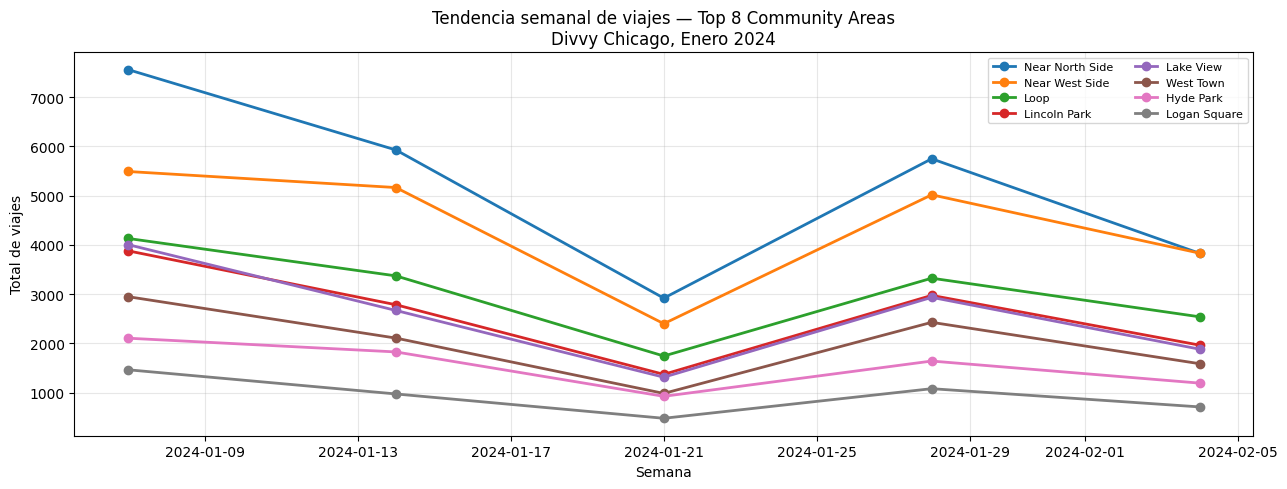

In [ ]:
# Tendencia semanal para el top 8
fig, ax = plt.subplots(figsize=(13, 5))  # crea la figura y un solo eje con tamaño 13x5

colores = plt.cm.tab10.colors  # paleta de colores predefinida con 10 colores distintos

for i, area in enumerate(top8): # enumerate basically associate a number to each element.
    # recorre las 8 community areas más importantes
    # i = índice (para asignar color), area = nombre de la comunidad

    ax.plot(
        pivot_semanal.index,  # eje X: semanas
        pivot_semanal[area],  # eje Y: viajes por semana en esa comunidad
        marker='o',  # marca cada punto de datos
        linewidth=2,  # grosor de la línea
        markersize=6,  # tamaño de los puntos
        label=area,  # nombre que aparece en la leyenda
        color=colores[i]  # asigna un color distinto a cada comunidad
    )

ax.set_title('Tendencia semanal de viajes — Top 8 Community Areas\nDivvy Chicago, Enero 2024', fontsize=12)  # título del gráfico
ax.set_xlabel('Semana')  # etiqueta eje X
ax.set_ylabel('Total de viajes')  # etiqueta eje Y
ax.legend(fontsize=8, loc='upper right', ncol=2)  # muestra la leyenda con 2 columnas
ax.grid(alpha=0.3)  # activa la cuadrícula con transparencia
plt.tight_layout()  # ajusta espacios para que no se solapen elementos
plt.show()  # muestra el gráfico final

## 6. Análisis por tipo de usuario: member vs casual por zona

Podemos agregar una tercera dimensión al análisis: además de la semana y el community area, separar por tipo de usuario. Esto nos permite ver si hay zonas donde los usuarios casuales son dominantes y si ese patrón cambia durante el mes.

In [ ]:
# Porcentaje de viajes casuales por community area
resumen_usuario = (
    df_clean  # dataset limpio con los viajes
    .groupby(['community', 'member_casual'])['ride_id']  # agrupa por community area y tipo de usuario
    .count()  # cuenta cuántos viajes hay en cada grupo
    .unstack(fill_value=0)  # convierte member_casual en columnas ('casual' y 'member')
)

resumen_usuario['total'] = resumen_usuario.sum(axis=1) # calcula el total de viajes por community area (casual + member)

resumen_usuario['pct_casual'] = ( # calcula el porcentaje de viajes realizados por usuarios casuales
    resumen_usuario['casual'] / resumen_usuario['total'] * 100
).round(1)

print("Top 10 community areas por % de usuarios casuales:")

resumen_usuario.sort_values('pct_casual', ascending=False).head(10) # ordena de mayor a menor porcentaje de usuarios casuales y muestra las 10 primeras áreas

Top 10 community areas por % de usuarios casuales:


member_casual,casual,member,total,pct_casual
community,,,,
Calumet Heights,2,0,2,100.0
Hegewisch,19,3,22,86.4
Pullman,11,2,13,84.6
Montclare,18,4,22,81.8
Mount Greenwood,6,2,8,75.0
Ohare,3,1,4,75.0
Gage Park,45,17,62,72.6
Ashburn,21,8,29,72.4
Chicago Lawn,40,16,56,71.4


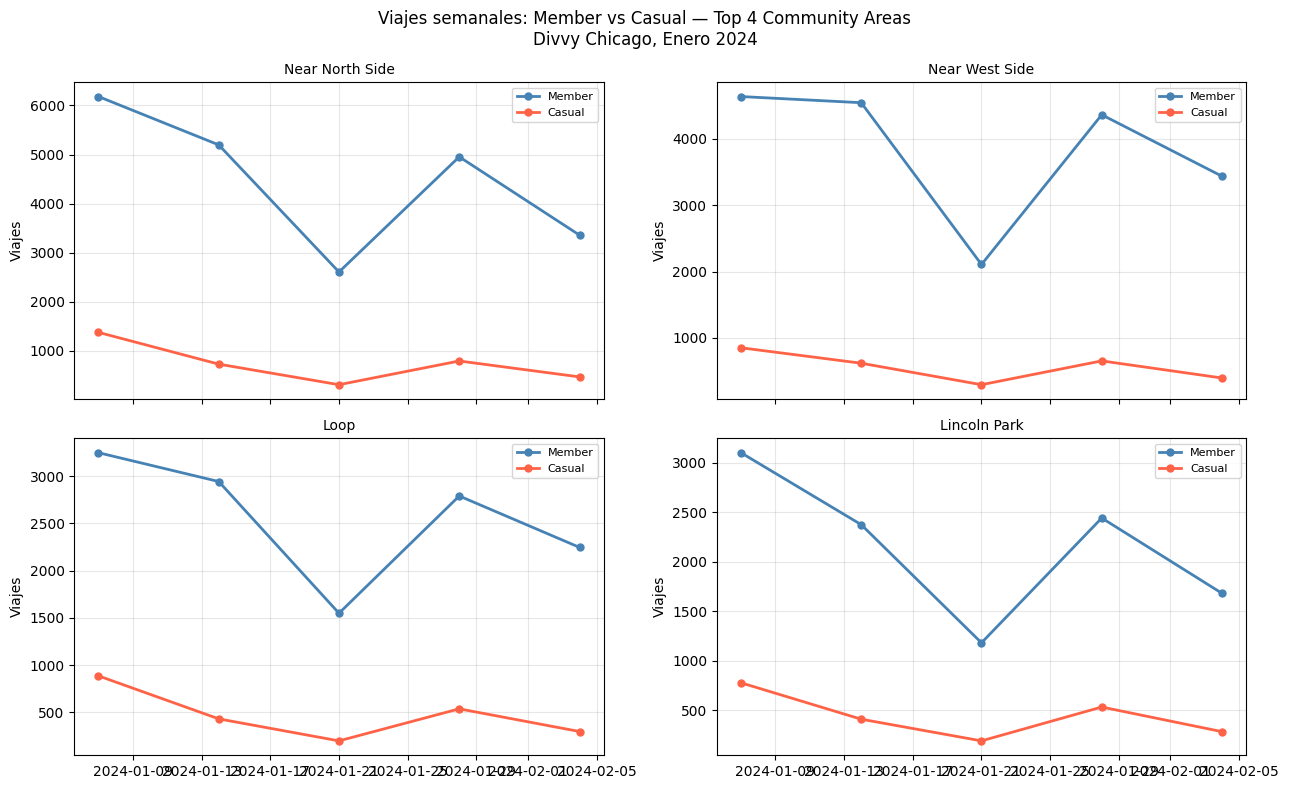

In [ ]:
# Resampling semanal separado por tipo de usuario — para los top 4

top4 = top8[:4]  # selecciona las 4 community areas con más viajes

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True) # crea una cuadrícula de 2x2 gráficos y comparte el eje X entre ellos

axes = axes.flatten() # convierte la matriz de ejes en una lista para recorrerla fácilmente

for i, area in enumerate(top4):
    ax = axes[i]  # selecciona el subplot correspondiente a la comunidad actual
    datos_area = df_clean[df_clean['community'] == area] # filtra los datos para quedarse solo con esa community area

    for tipo, color in [('member', 'steelblue'), ('casual', 'tomato')]: # recorre los dos tipos de usuarios y asigna un color a cada uno

        serie = (
            datos_area[datos_area['member_casual'] == tipo] # filtra los viajes del tipo de usuario actual
            .resample('W')['ride_id'] # agrupa los viajes por semana
            .count() # cuenta cuántos viajes hubo cada semana
        )

        ax.plot(
            serie.index,  # eje X: semanas
            serie.values,  # eje Y: número de viajes
            marker='o',  # muestra un punto en cada observación
            linewidth=2,  # grosor de la línea
            markersize=5,  # tamaño de los marcadores
            label=tipo.capitalize(),  # etiqueta para la leyenda
            color=color  # color de la línea
        )

    ax.set_title(area, fontsize=10)  # nombre de la community area
    ax.set_ylabel('Viajes')  # etiqueta eje Y
    ax.grid(alpha=0.3)  # añade cuadrícula ligera
    ax.legend(fontsize=8)  # muestra la leyenda

fig.suptitle(
    'Viajes semanales: Member vs Casual — Top 4 Community Areas\nDivvy Chicago, Enero 2024',
    fontsize=12
)
# título general de toda la figura

plt.tight_layout()  # ajusta los espacios entre subgráficos
plt.show()  # muestra la figura final

## 7. Evolución espacial semana a semana

Ahora vamos a ver cómo cambia la distribución geográfica de los viajes durante el mes. Para esto hacemos un mapa por cada semana, con una escala de color fija para que los mapas sean comparables entre sí.

Es importante que la escala (`vmin` y `vmax`) sea la misma en todos los mapas — si cada uno usara su propia escala, las diferencias visuales no serían interpretables.

In [ ]:
# Preparar datos: viajes por community area y semana como tabla larga
df_clean_reset = df_clean.copy() # crea una copia del dataset para trabajar sin modificar el original
df_clean_reset['semana'] = df_clean_reset.index.to_period('W') # convierte el índice de fechas en períodos semanales y los guarda en una nueva columna

viajes_semana_zona = (
    df_clean_reset
    .groupby(['semana', 'community']) # agrupa los registros por semana y community area
    .size() # cuenta cuántos viajes hay en cada combinación (semana, community area). size() cuenta cuántas filas hay
    .reset_index(name='total_viajes') # convierte el resultado en un DataFrame y nombra la columna que acabamos de crear 'total_viajes'
)

semanas = sorted(viajes_semana_zona['semana'].unique()) # obtiene la lista de semanas únicas y las ordena cronológicamente

print(f"Semanas disponibles: {len(semanas)}") # muestra cuántas semanas hay en los datos

for s in semanas:
    print(f"  {s}")
    # imprime cada semana disponible

Semanas disponibles: 5
  2024-01-01/2024-01-07
  2024-01-08/2024-01-14
  2024-01-15/2024-01-21
  2024-01-22/2024-01-28
  2024-01-29/2024-02-04


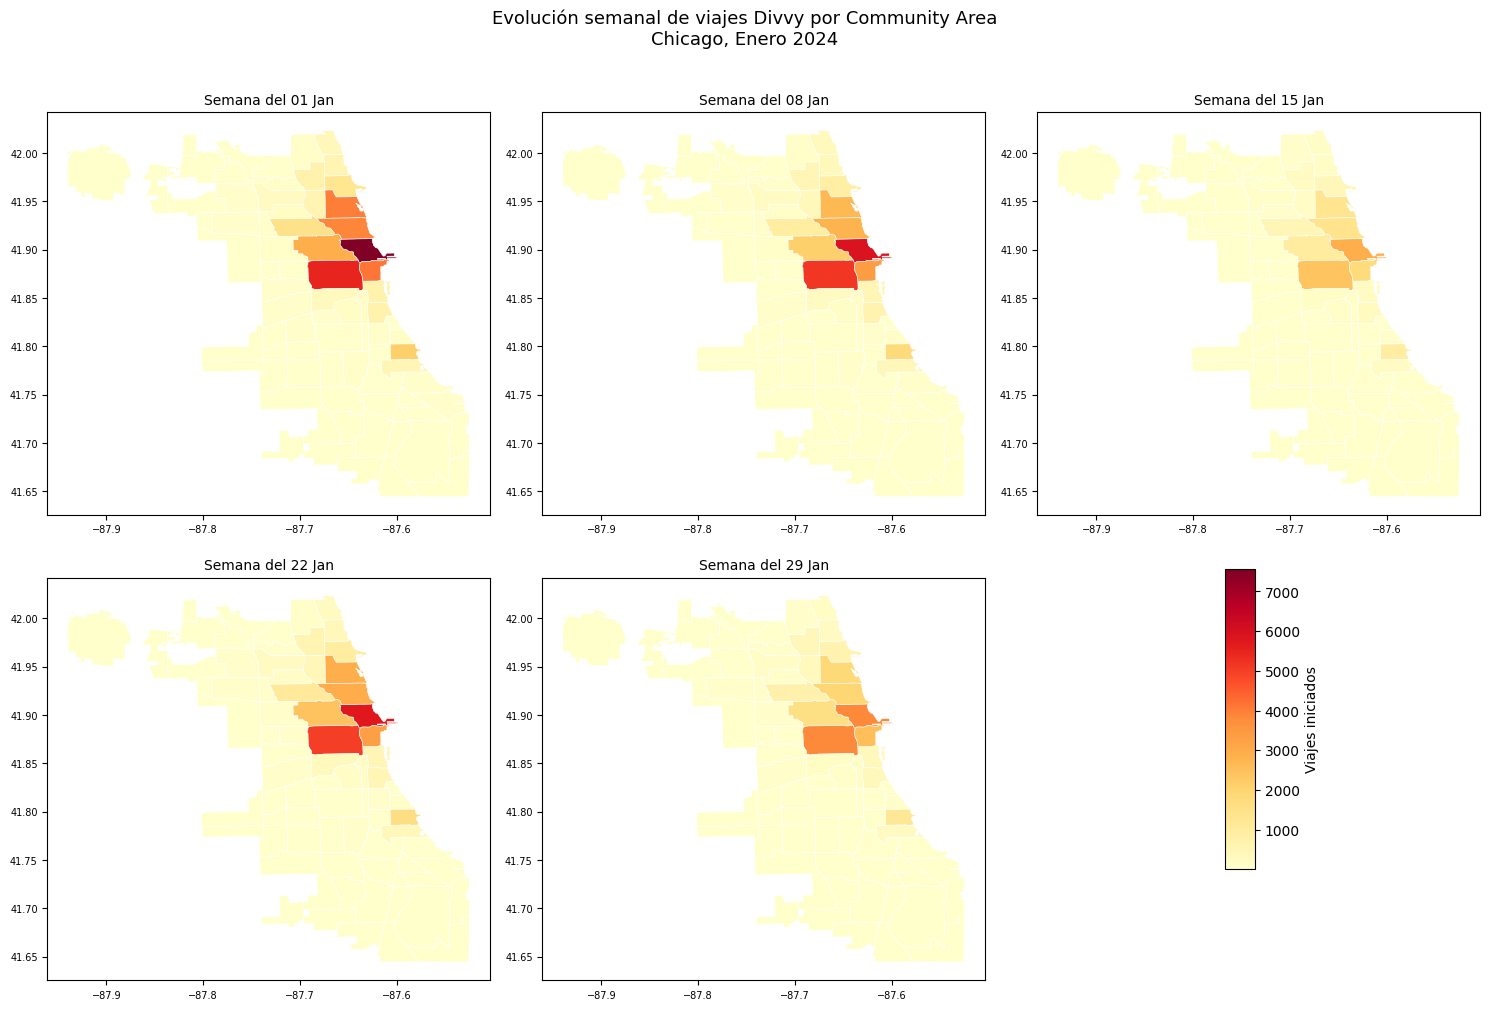

In [ ]:
# Plot de la evolución espacial semana a semana

# Definir límites globales de la escala para que todas las semanas sean comparables
vmin = viajes_semana_zona['total_viajes'].min()
vmax = viajes_semana_zona['total_viajes'].max()


# Crear la figura y aplanar la matriz de ejes a 1D para iterar fácilmente
fig, axes = plt.subplots(2, 3, figsize=(15, 2 * 5))
axes = axes.flatten()

for i, semana in enumerate(semanas):
    ax = axes[i]

    # Filtrar datos de la semana actual y cruzarlos con el GeoDataFrame base
    datos_semana = viajes_semana_zona[viajes_semana_zona['semana'] == semana]
    mapa_semana = comunidades.merge(
        datos_semana[['community', 'total_viajes']],
        on='community',
        how='left'
    )
    mapa_semana['total_viajes'] = mapa_semana['total_viajes'].fillna(0)  # Zonas sin viajes quedan en cero

    # Graficar el mapa coroplético de la semana con la escala de color fija (vmin/vmax)
    mapa_semana.plot(
        ax=ax,
        column='total_viajes',
        cmap='YlOrRd',
        edgecolor='white',
        linewidth=0.4,
        vmin=vmin,
        vmax=vmax
    )

    # Estilizado del subplot: título formateado, remover etiquetas y fijar aspecto cartográfico
    ax.set_title(f"Semana del {semana.start_time.strftime('%d %b')}", fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')  # Evita que el mapa se deforme geográficamente
    ax.tick_params(labelsize=7)

# Ocultar subplots vacíos si el número de semanas no llena la última fila
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Instancia un mapeador escalar abstracto independiente que asocia rangos numéricos directos con la paleta de colores.
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=vmin, vmax=vmax))
# Inicializa el mapeador con una lista vacía de datos obligatoria para que Matplotlib no intente renderizar una geometría oculta.
sm.set_array([])
# Dibuja la barra de color unificada apuntando
cax = fig.add_axes([0.82, 0.15, 0.02, 0.3]) # tweak color bar position
# Draw the colorbar inside that exact layout box
fig.colorbar(sm, cax=cax, label='Viajes iniciados')

# Título principal y ajuste de márgenes para evitar solapamientos
fig.suptitle('Evolución semanal de viajes Divvy por Community Area\nChicago, Enero 2024',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Análisis de concentración: ¿qué % del total genera cada zona?

En enero, ¿cuántos community areas concentran el 50% de los viajes? Esta pregunta de distribución es útil para priorizar donde enfocar operaciones (mantenimiento de bicicletas, redistribución de flota, etc.).

In [ ]:
# Calcular porcentaje acumulado de viajes por community area
total_por_zona = (
    df_clean.groupby('community')['ride_id']  # Agrupa los datos por barrio (Community Area) y selecciona el ID del viaje.
    .count()                                  # Cuenta el volumen total de viajes iniciados en cada barrio.
    .sort_values(ascending=False)             # Ordena las zonas de mayor a menor afluencia (análisis de Pareto).
    .reset_index()                            # Transforma los índices de la agrupación en columnas limpias.
)
total_por_zona.columns = ['community', 'viajes']  # Renombra las columnas para que el DataFrame sea autoexplicativo.
total_por_zona['pct'] = (total_por_zona['viajes'] / total_por_zona['viajes'].sum() * 100).round(2)  # Calcula el % de aporte individual de cada zona.
total_por_zona['pct_acum'] = total_por_zona['pct'].cumsum().round(2)  # Calcula el % acumulado para identificar la concentración de la demanda.

# ¿Cuántas zonas concentran el 50% de los viajes?
zonas_50pct = total_por_zona[total_por_zona['pct_acum'] <= 50].shape[0] + 1  # Cuenta cuántos barrios suman el primer 50% del mercado global.
print(f"Las primeras {zonas_50pct} community areas concentran el 50% de los viajes de enero.")  # Imprime el conteo absoluto de zonas críticas.
print(f"Eso es el {zonas_50pct/77*100:.0f}% de las {77} zonas de Chicago.")  # Muestra la proporción relativa frente al total de la ciudad (77 barrios).
print()
total_por_zona.head(10)  # Despliega el Top 10 de las zonas más activas para inspección visual.

Las primeras 4 community areas concentran el 50% de los viajes de enero.
Eso es el 5% de las 77 zonas de Chicago.



,community,viajes,pct,pct_acum
0,Near North Side,25987,18.83,18.83
1,Near West Side,21908,15.88,34.71
2,Loop,15115,10.95,45.66
3,Lincoln Park,12982,9.41,55.07
4,Lake View,12812,9.28,64.35
5,West Town,10063,7.29,71.64
6,Hyde Park,7700,5.58,77.22
7,Logan Square,4716,3.42,80.64
8,Uptown,4190,3.04,83.68
9,Douglas,2464,1.79,85.47


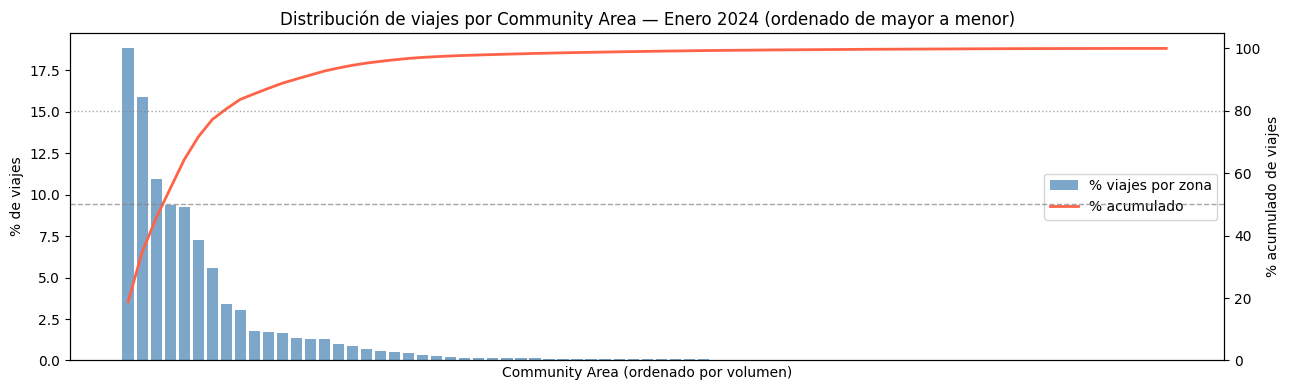

In [ ]:
# Curva de Pareto: porcentaje acumulado de viajes

fig, ax = plt.subplots(figsize=(13, 4)) # Crear lienzo base y el eje principal (izquierdo)

# Eje Izquierdo: Barras del porcentaje individual por barrio
ax.bar(range(len(total_por_zona)), total_por_zona['pct'],
       color='steelblue', alpha=0.7, label='% viajes por zona')

# Crear eje Y espejo (derecho) compartiendo el mismo eje X
ax2 = ax.twinx()
# Eje Derecho: Línea del porcentaje acumulado
ax2.plot(range(len(total_por_zona)), total_por_zona['pct_acum'],
         color='tomato', linewidth=2, label='% acumulado')
# Líneas de referencia fijas en 50% y 80%
ax2.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.axhline(80, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax2.set_ylabel('% acumulado de viajes')
ax2.set_ylim(0, 105)

# Títulos y etiquetas del eje principal
ax.set_title('Distribución de viajes por Community Area — Enero 2024 (ordenado de mayor a menor)')
ax.set_xlabel('Community Area (ordenado por volumen)')
ax.set_ylabel('% de viajes')
ax.set_xticks([]) # Oculta los 77 nombres en el eje X para evitar solapamientos

# Recuperar elementos de ambos ejes para unirlos en una sola leyenda
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

# Ajustar márgenes y renderizar figura
plt.tight_layout()
plt.show()

## 9. Dashboard integrado: tendencia + mapa en una figura

Cerramos el análisis con un dashboard que combine en una sola figura las dos visualizaciones más informativas: la tendencia semanal de los top community areas y el mapa de calor acumulado del mes.

Usamos `GridSpec` para controlar el tamaño relativo de cada panel.

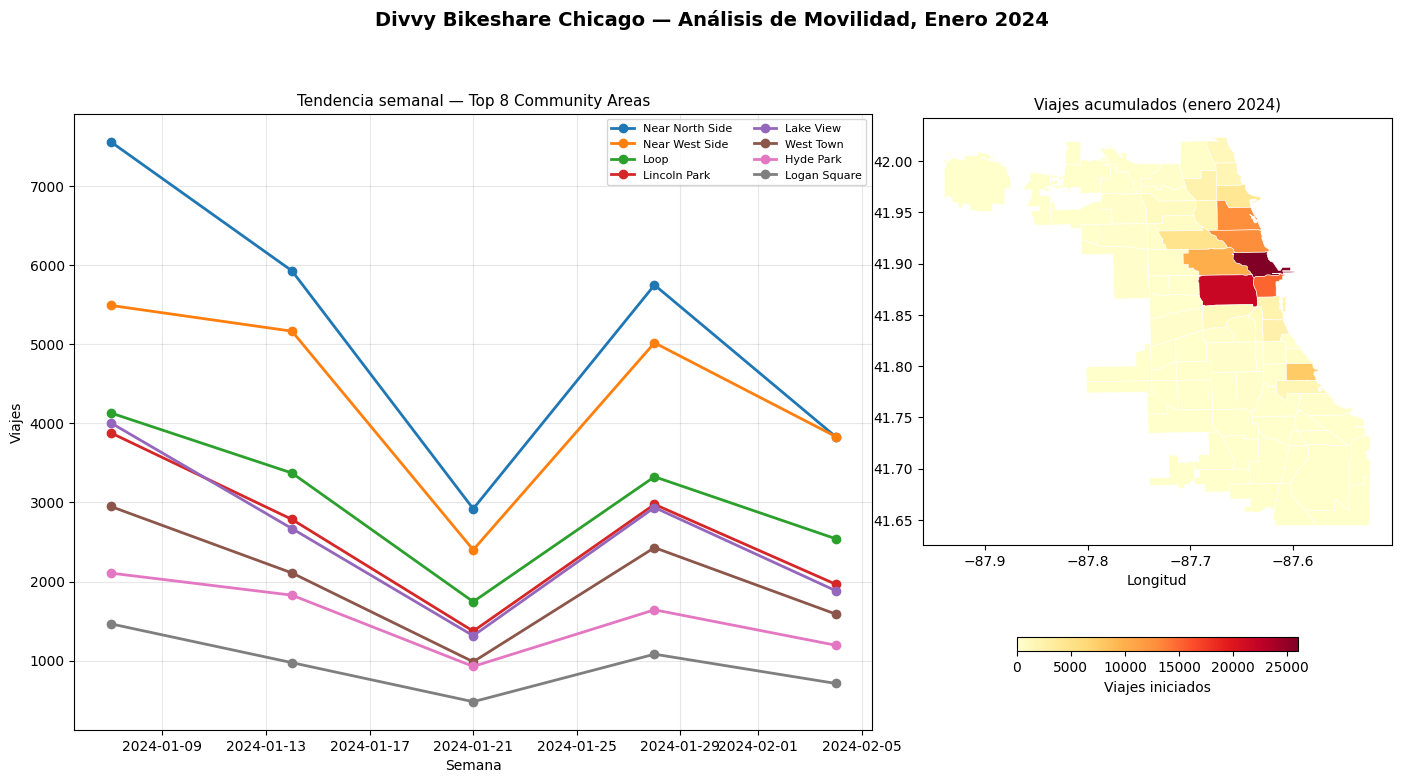

In [ ]:
# Preparar datos para el mapa acumulado
metricas_acum = comunidades.merge(
    total_por_zona[['community', 'viajes', 'pct']],
    on='community',
    how='left'
)
metricas_acum['viajes'] = metricas_acum['viajes'].fillna(0)

# Construir el dashboard
fig = plt.figure(figsize=(17, 8))
gs = GridSpec(1, 2, width_ratios=[1.7, 1], figure=fig, wspace=0.08)

ax_lineas = fig.add_subplot(gs[0])
ax_mapa   = fig.add_subplot(gs[1])

# --- Panel izquierdo: tendencia semanal top 8 ---
for i, area in enumerate(top8):
    ax_lineas.plot(
        pivot_semanal.index,
        pivot_semanal[area],
        marker='o',
        linewidth=2,
        markersize=6,
        label=area,
        color=colores[i]
    )

ax_lineas.set_title('Tendencia semanal — Top 8 Community Areas', fontsize=11)
ax_lineas.set_xlabel('Semana')
ax_lineas.set_ylabel('Viajes')
ax_lineas.legend(fontsize=8, ncol=2)
ax_lineas.grid(alpha=0.3)

# --- Panel derecho: mapa de calor acumulado ---
metricas_acum.plot(
    ax=ax_mapa,
    column='viajes',
    cmap='YlOrRd',
    edgecolor='white',
    linewidth=0.4,
    legend=True,
    legend_kwds={'label': 'Viajes iniciados', 'shrink': 0.6, 'orientation': 'horizontal'}
)
ax_mapa.set_title('Viajes acumulados (enero 2024)', fontsize=11)
ax_mapa.set_xlabel('Longitud')
ax_mapa.set_ylabel('')
ax_mapa.set_aspect('equal')

fig.suptitle('Divvy Bikeshare Chicago — Análisis de Movilidad, Enero 2024',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

**Fin de la Fase 3 y del laboratorio completo.**

En estas tres sesiones pasamos de un archivo ZIP con datos brutos a un análisis integrado temporal y geoespacial sobre datos reales de movilidad urbana: limpieza, ingeniería de features, proyección espacial, spatial join con vecindarios reales, resampling por zona y visualizaciones de dashboard. Ese flujo es el núcleo del trabajo de análisis de datos aplicado.